In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [8]:
# Load cleaned data for calculations
df = pd.read_csv("cleaned_dataset_supplychain.csv")
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_date'] = df['order date (DateOrders)'].dt.normalize()

# Load dead stock output
dead_stock = pd.read_csv("dead_stock_output.csv")

# Load demand forecast output
demand_out = pd.read_csv("demand_forecast_output.csv")

print("Cleaned data:", df.shape)
print("Dead stock products:", len(dead_stock))
print("Demand forecast rows:", len(demand_out))

Cleaned data: (180519, 54)
Dead stock products: 118
Demand forecast rows: 60


In [9]:
# Recalculate with stricter thresholds so not every product is flagged
DAYS_THRESHOLD     = 180    # raised from 90 to 180 days
VELOCITY_THRESHOLD = 0.2    # lowered from 0.5 to 0.2 units/week

dead_stock['dead_stock_revised'] = (
    (dead_stock['days_since_last_sale'] >= DAYS_THRESHOLD) &  # AND not OR
    (dead_stock['weekly_sales_velocity'] <= VELOCITY_THRESHOLD)
).astype(int)

# Revised recommendation
def revised_recommend(row):
    if row['dead_stock_revised'] == 1:
        if row['days_since_last_sale'] > 365:
            return 'LIQUIDATE'
        else:
            return 'DISCOUNT'
    elif row['ABC'] == 'A':
        return 'MAINTAIN STOCK'
    elif row['ABC'] == 'B':
        return 'MONITOR'
    else:
        return 'REVIEW'

dead_stock['recommendation'] = dead_stock.apply(revised_recommend, axis=1)

print("Revised recommendation breakdown:")
print(dead_stock['recommendation'].value_counts())

Revised recommendation breakdown:
recommendation
REVIEW            95
MONITOR           16
MAINTAIN STOCK     7
Name: count, dtype: int64


In [10]:
# Per product: demand, lead time, price
product_stats = df.groupby('Product Name').agg(
    avg_daily_demand = ('Order Item Quantity',
                        lambda x: x.sum() / max(df['order_date'].nunique(), 1)),
    std_daily_demand = ('Order Item Quantity', 'std'),
    avg_lead_time    = ('Days for shipping (real)', 'mean'),
    std_lead_time    = ('Days for shipping (real)', 'std'),
    avg_unit_price   = ('Product Price', 'mean'),
    total_units_sold = ('Order Item Quantity', 'sum')
).reset_index().fillna(0)

print("Product stats shape:", product_stats.shape)
print(product_stats.head(3))

Product stats shape: (118, 7)
              Product Name  avg_daily_demand  std_daily_demand  avg_lead_time  \
0       Adult dog supplies          0.436557          0.000000       3.388211   
1             Baby sweater          0.183673          0.000000       3.149758   
2  Bag Boy Beverage Holder          0.749778          1.449101       3.602151   

   std_lead_time  avg_unit_price  total_units_sold  
0       1.656224       84.400002               492  
1       1.712826       59.080002               207  
2       1.553412       24.990000               845  


In [11]:
Z             = 1.65    # 95% service level
ORDERING_COST = 50      # fixed cost per order placed
HOLDING_RATE  = 0.20    # 20% of unit price per year as holding cost

def safety_stock(row):
    # Formula: Z × sqrt(L×σd² + D²×σL²)
    # L = avg lead time, σd = std of demand
    # D = avg demand,   σL = std of lead time
    L    = row['avg_lead_time']
    sig_d = row['std_daily_demand']
    D    = row['avg_daily_demand']
    sig_L = row['std_lead_time']
    ss = Z * np.sqrt(L * sig_d**2 + D**2 * sig_L**2)
    return round(max(ss, 0), 1)

def reorder_point(row):
    # Formula: avg_demand × avg_lead_time + safety_stock
    rop = row['avg_daily_demand'] * row['avg_lead_time'] + row['safety_stock']
    return round(max(rop, 0), 1)

def eoq(row):
    # Formula: sqrt(2 × annual_demand × ordering_cost / holding_cost)
    D_annual     = row['avg_daily_demand'] * 365
    unit_cost    = max(row['avg_unit_price'], 0.01)
    holding_cost = unit_cost * HOLDING_RATE
    if holding_cost == 0 or D_annual == 0:
        return 1
    result = np.sqrt((2 * D_annual * ORDERING_COST) / holding_cost)
    return max(round(result), 1)

product_stats['safety_stock']  = product_stats.apply(safety_stock, axis=1)
product_stats['reorder_point'] = product_stats.apply(reorder_point, axis=1)
product_stats['eoq']           = product_stats.apply(eoq, axis=1)

print("Inventory parameters computed ✅")
print(product_stats[['Product Name', 'avg_daily_demand',
                      'safety_stock', 'reorder_point', 'eoq']].head(8))

Inventory parameters computed ✅
                                    Product Name  avg_daily_demand  \
0                             Adult dog supplies          0.436557   
1                                   Baby sweater          0.183673   
2                        Bag Boy Beverage Holder          0.749778   
3                         Bag Boy M330 Push Cart          0.184561   
4              Bowflex SelectTech 1090 Dumbbells          0.008873   
5  Bridgestone e6 Straight Distance NFL Carolina          0.823425   
6  Bridgestone e6 Straight Distance NFL San Dieg          0.803904   
7  Bridgestone e6 Straight Distance NFL Tennesse          0.714286   

   safety_stock  reorder_point  eoq  
0           1.2            2.7   31  
1           0.5            1.1   24  
2           4.9            7.6   74  
3           3.9            4.5   21  
4           0.0            0.0    2  
5           4.9            7.9   69  
6           4.8            7.6   68  
7           5.2            7.8   

In [12]:
final_df = product_stats.merge(
    dead_stock[[
        'Product Name', 'ABC', 'XYZ', 'ABC_XYZ',
        'days_since_last_sale', 'weekly_sales_velocity',
        'dead_stock_revised', 'recommendation'
    ]],
    on='Product Name',
    how='left'
)

final_df['recommendation'] = final_df['recommendation'].fillna('MONITOR')
print("Merged shape:", final_df.shape)

Merged shape: (118, 17)


In [13]:

def final_action(row):
    if row['recommendation'] == 'LIQUIDATE':
        return 'LIQUIDATE — stop reordering, clear stock'
    elif row['recommendation'] == 'DISCOUNT':
        return 'DISCOUNT — run promotion to clear'
    elif row['avg_daily_demand'] <= 0:
        return 'REVIEW — zero demand detected'
    else:
        return (f"REORDER {int(row['eoq'])} units "
                f"when stock hits {int(row['reorder_point'])}")

final_df['action'] = final_df.apply(final_action, axis=1)

# Action summary
print("Action breakdown:")
action_summary = final_df['action'].apply(
    lambda x: x.split(' ')[0]
).value_counts()
print(action_summary)

Action breakdown:
action
REORDER    118
Name: count, dtype: int64


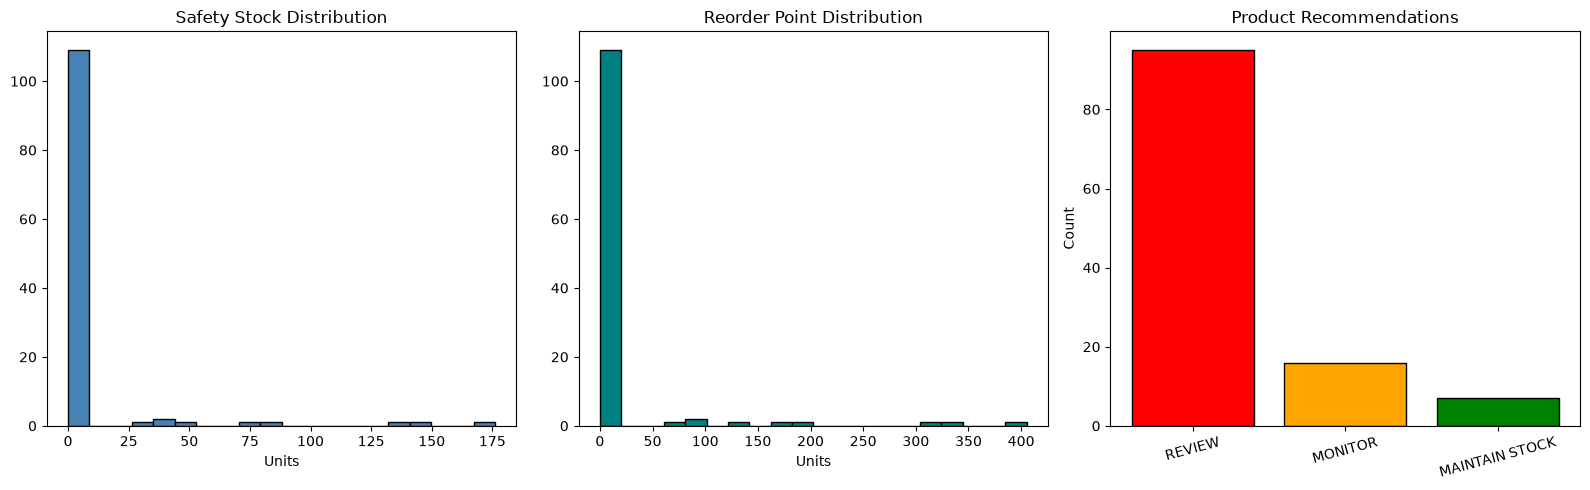

Plots saved ✅


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Safety stock distribution
axes[0].hist(
    final_df['safety_stock'].clip(0, 200),
    bins=20, color='steelblue', edgecolor='black'
)
axes[0].set_title('Safety Stock Distribution')
axes[0].set_xlabel('Units')

# Plot 2 — Reorder point distribution
axes[1].hist(
    final_df['reorder_point'].clip(0, 500),
    bins=20, color='teal', edgecolor='black'
)
axes[1].set_title('Reorder Point Distribution')
axes[1].set_xlabel('Units')

# Plot 3 — Recommendation breakdown
rec_counts = final_df['recommendation'].value_counts()
axes[2].bar(
    rec_counts.index, rec_counts.values,
    color=['red','orange','green','steelblue','gray'],
    edgecolor='black'
)
axes[2].set_title('Product Recommendations')
axes[2].set_ylabel('Count')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=15)

plt.tight_layout()
plt.savefig("inventory_optimization_plots.png")
plt.show()
print("Plots saved ✅")

In [15]:
output_cols = [
    'Product Name', 'ABC_XYZ',
    'avg_daily_demand', 'avg_lead_time',
    'safety_stock', 'reorder_point', 'eoq',
    'days_since_last_sale', 'weekly_sales_velocity',
    'recommendation', 'action'
]

final_output = final_df[output_cols].round(2)
final_output.to_csv("final_inventory_recommendations.csv", index=False)
print("Final recommendations saved ✅")

Final recommendations saved ✅


In [16]:
reorder_count  = final_df['action'].str.startswith('REORDER').sum()
liquidate_count = (final_df['recommendation'] == 'LIQUIDATE').sum()
discount_count  = (final_df['recommendation'] == 'DISCOUNT').sum()

print("=" * 45)
print("   INVENTORY OPTIMIZATION COMPLETE")
print("=" * 45)
print(f"  Total products analysed : {len(final_df)}")
print(f"  Products to REORDER     : {reorder_count}")
print(f"  Products to LIQUIDATE   : {liquidate_count}")
print(f"  Products to DISCOUNT    : {discount_count}")
print(f"  Avg safety stock        : {final_df['safety_stock'].mean():.1f} units")
print(f"  Avg reorder point       : {final_df['reorder_point'].mean():.1f} units")
print(f"  Output saved            : final_inventory_recommendations.csv")
print("=" * 45)

   INVENTORY OPTIMIZATION COMPLETE
  Total products analysed : 118
  Products to REORDER     : 118
  Products to LIQUIDATE   : 0
  Products to DISCOUNT    : 0
  Avg safety stock        : 9.3 units
  Avg reorder point       : 19.4 units
  Output saved            : final_inventory_recommendations.csv
